In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [2]:
train = train.copy()

In [3]:
train.head(10)

,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427
5,N102,4320000.0,1484.585083,17.033432
6,N102,5184000.0,1483.909058,17.430515
7,N102,6048000.0,1483.233154,17.254442
8,N102,6912000.0,1482.557251,17.905001
9,N102,7776000.0,1481.881226,17.375288


In [4]:
train.shape

(6626928, 4)

In [5]:
#sensors.plot(kind='scatter', x='coor_x', y='coor_y')

In [6]:
#train.plot(kind='scatter', x='time', y='power')

In [7]:
#train.plot(kind='scatter', x='time', y='temperature', alpha=0.3)

In [8]:
#view of possible outliers --> here we see two 'bad' sensors
#train.plot(kind='scatter', x='sensor', y='temperature')

In [9]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [10]:
#see if we have missing values --> some in temperature
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [11]:
#visualise how many missing values
missing_idx = train[train['temperature'].isna()].index
print(missing_idx)
print(len(missing_idx))

Index([    106,     364,     477,     501,     568,     657,     712,     769,
           833,     870,
       ...
       6626263, 6626302, 6626312, 6626504, 6626575, 6626627, 6626671, 6626726,
       6626890, 6626924],
      dtype='int64', length=99403)
99403


<Axes: xlabel='coor_x', ylabel='coor_y'>

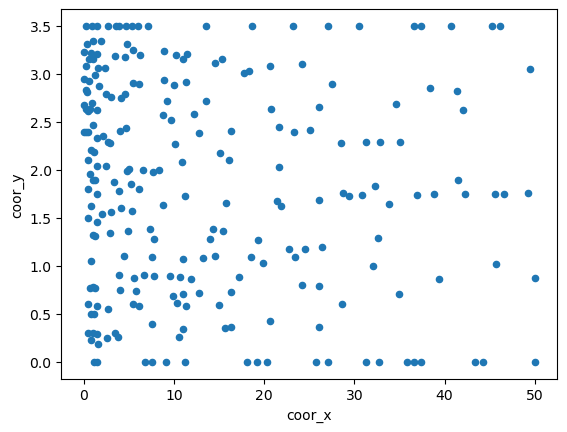

In [12]:
#see where the missing values are --> a bit everywhere, which doesn't help us much 
sensors_misval = train.loc[missing_idx, 'sensor'].unique()
sensors_misval_coords = sensors[sensors['sensor'].isin(sensors_misval)]

sensors_misval_coords.plot(kind='scatter', x='coor_x', y='coor_y')
#plt.show()

In [13]:
#fills the missing temperature by using interpolate because our data is ordered chronologically 
#and taking into account ouly values from the same sensor
train['temperature'] = (
    train.groupby('sensor')['temperature']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

In [14]:
#control that every missing values are replaced
train.isna().any() 

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [15]:
#finding the number of the two sensors which are very far from our expected values; outliers
neg_outlier = train[train['temperature'] == train['temperature'].min()]
pos_outlier = train[train['temperature'] == train['temperature'].max()]
print(neg_outlier['sensor'], pos_outlier['sensor'])

483784     N277
483785     N277
483786     N277
483787     N277
483788     N277
           ... 
4910859    N277
4910860    N277
4910861    N277
4910862    N277
4910863    N277
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96'] 2181592    N927
2181593    N927
2181594    N927
2181595    N927
2181596    N927
           ... 
6608667    N927
6608668    N927
6608669    N927
6608670    N927
6608671    N927
Name: sensor, Length: 27384, dtype: category
Categories (242, str): ['N102', 'N103', 'N108', 'N112', ..., 'N926', 'N927', 'N928', 'N96']


In [16]:
#get rid of the outlier sensors
train = train[train["sensor"] != "N277"]
train = train[train["sensor"] != "N927"]
sensors = sensors[sensors["sensor"] != "N277"]
sensors = sensors[sensors["sensor"] != "N927"]

In [17]:
#verify that the outlier sensors are gone
np.all(train["sensor"] != 'N277') and np.all(train["sensor"] != 'N927')

np.True_

In [18]:
#temperatures per sensors after getting rid of the two bad sensors
#train.plot(kind='scatter', x='sensor', y='temperature', alpha=0.15)

(2190720, 4) (2190720, 4) (2190720, 4)


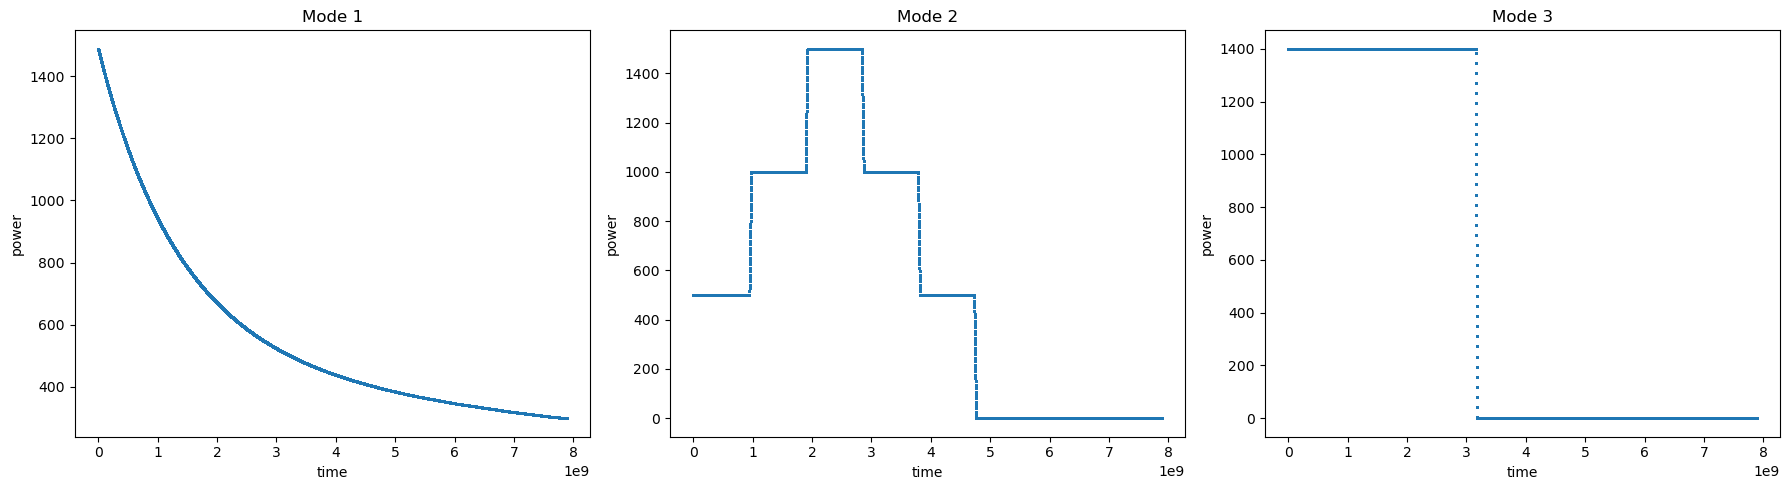

In [19]:
#separate out three modes so that we can try different models for different modes
BLOCK = len(train) // 3

mode1 = train.iloc[0       : BLOCK].copy()
mode2 = train.iloc[BLOCK   : 2*BLOCK].copy()
mode3 = train.iloc[2*BLOCK :].copy()

# Vérification
print(mode1.shape, mode2.shape, mode3.shape)

# Visualiser les 3 modes séparément
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='power', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='power', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='power', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

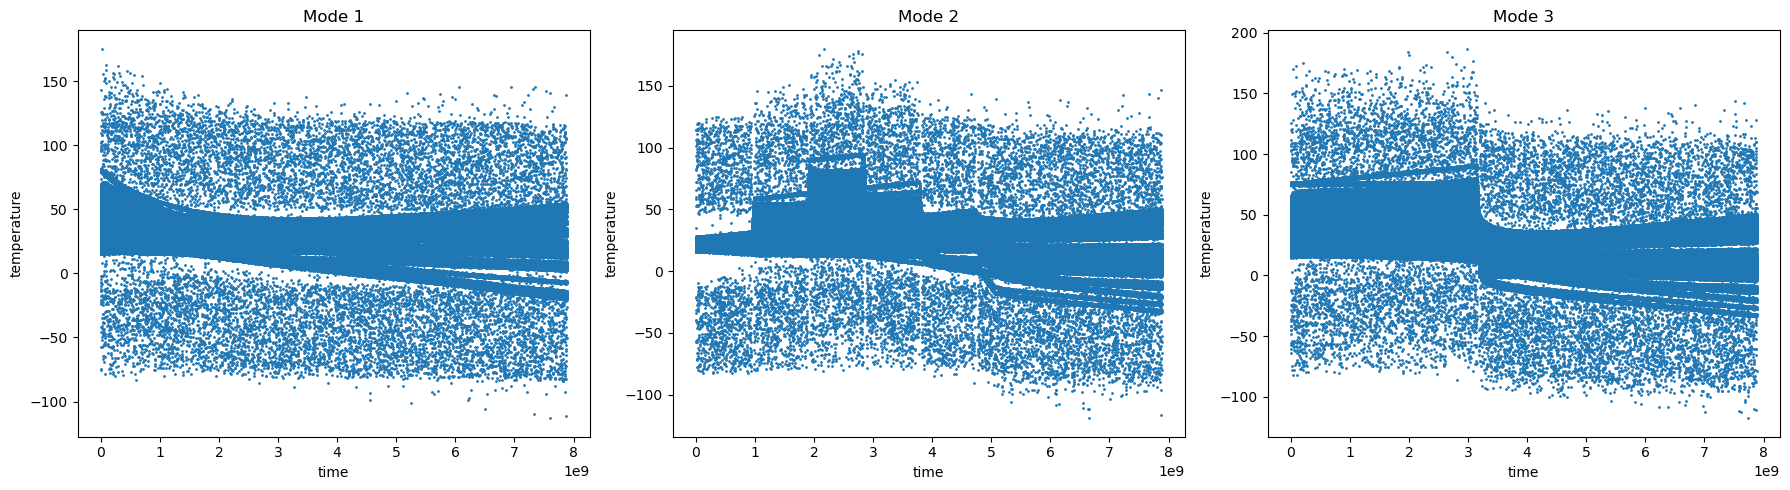

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mode1.plot(kind='scatter', x='time', y='temperature', ax=axes[0], title='Mode 1', s=1)
mode2.plot(kind='scatter', x='time', y='temperature', ax=axes[1], title='Mode 2', s=1)
mode3.plot(kind='scatter', x='time', y='temperature', ax=axes[2], title='Mode 3', s=1)

plt.tight_layout()
plt.show()

KNN

In [21]:
from typing import Optional, Tuple, List, Dict
#Transforms data into numpy arrays and splits it into a train, val and test set
def preprocess_data(
    df: pd.DataFrame,
    label: str,
    train_size: float = 0.6,
    val_size: float = 0.2,
    seed: Optional[int] = None,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    List[str],
    Dict[int, str],
]:

    df = df.sort_values(by=label)
    df[label] = df[label].astype("category")

    df = df.sample(frac=1, random_state=seed)
    train, val, test = (
        df[: int(len(df) * train_size)],
        df[int(len(df) * train_size) : int(len(df) * (train_size + val_size))],
        df[int(len(df) * (train_size + val_size)) :],
    )

    X_train = train.drop(columns=label).to_numpy()
    X_val = val.drop(columns=label).to_numpy()
    X_test = test.drop(columns=label).to_numpy()

    y_train = train[label].cat.codes.to_numpy()
    y_val = val[label].cat.codes.to_numpy()
    y_test = test[label].cat.codes.to_numpy()

    label_map = dict(enumerate(df[label].cat.categories))
    feature_names = list(df.drop(columns=label).columns)

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_names, label_map

In [22]:
X_train, y_train, X_val, y_val, X_test, y_test, feature_names, label_map = preprocess_data(df=train, label="temperature", train_size=0.6, val_size=0.2, seed=42)

In [23]:
print(X_train)

[['N798' 3124483200.0 1000.0]
 ['N234' 301536000.0 1278.6170654296875]
 ['N622' 4203792000.0 426.07562255859375]
 ...
 ['N464' 3252441600.0 1000.0]
 ['N312' 5559580800.0 0.0]
 ['N57' 809654400.0 1018.45751953125]]


In [24]:
sensors.head()

,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0


In [ ]:
# Get unique sensor names from the first column
sensor_names_train = X_train[:, 0]
sensor_names_val = X_val[:, 0]
sensor_names_test = X_test[:, 0]

# Create dictionary mapping sensor name -> number
sensor_dict = {name: idx for idx, name in enumerate(sensors["sensor"])}

# Replace sensor names with their assigned numbers
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()
X_train_encoded[:, 0] = np.array([sensor_dict[name] for name in sensor_names_train])
X_val_encoded[:, 0] = np.array([sensor_dict[name] for name in sensor_names_val])
X_test_encoded[:, 0] = np.array([sensor_dict[name] for name in sensor_names_test])

print("Sensor dictionary:", sensor_dict)

Sensor dictionary: {'N2': 0, 'N4': 1, 'N5': 2, 'N6': 3, 'N7': 4, 'N8': 5, 'N11': 6, 'N12': 7, 'N182': 8, 'N183': 9, 'N184': 10, 'N185': 11, 'N186': 12, 'N187': 13, 'N188': 14, 'N196': 15, 'N197': 16, 'N198': 17, 'N199': 18, 'N200': 19, 'N201': 20, 'N202': 21, 'N203': 22, 'N204': 23, 'N205': 24, 'N206': 128, 'N207': 26, 'N208': 27, 'N209': 28, 'N210': 29, 'N211': 30, 'N212': 31, 'N213': 129, 'N214': 33, 'N889': 34, 'N890': 35, 'N891': 36, 'N892': 37, 'N893': 38, 'N894': 39, 'N895': 40, 'N896': 41, 'N897': 42, 'N898': 43, 'N899': 44, 'N900': 45, 'N901': 46, 'N902': 47, 'N903': 48, 'N904': 49, 'N905': 50, 'N906': 51, 'N907': 52, 'N908': 53, 'N909': 54, 'N910': 55, 'N911': 56, 'N912': 57, 'N913': 58, 'N914': 59, 'N915': 60, 'N916': 61, 'N917': 62, 'N918': 63, 'N919': 64, 'N920': 65, 'N921': 66, 'N922': 67, 'N923': 68, 'N924': 69, 'N925': 70, 'N926': 71, 'N928': 72, 'N929': 73, 'N3': 74, 'N9': 75, 'N15': 76, 'N16': 77, 'N20': 78, 'N28': 79, 'N30': 80, 'N34': 81, 'N36': 82, 'N39': 83, 'N41':